# Plotting the distribution of refractive index in all tomobcube data

In [70]:
import sys
import json
from tqdm import tqdm
import imageio
import scipy as sc
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.ndimage  import gaussian_filter
from scipy.stats    import linregress
from scipy.optimize import curve_fit
from cmcrameri import cm

from matplotlib_scalebar.scalebar import ScaleBar


sys.path.append("scripts/utils/")
from Microscopes         import Tomocube, Holomonitor
from SegmentedCells      import SegmentedCells
from file_operations     import load_stack
from averaging_functions import compute_pdf_from_bins


### Files used for figures in paper on Three Dimensional Dynamics of Epithelial Monolayers

Fig. 1B: `250904.114139.MDCK-li.001.Group2.B1.T001P01_HT3D_10-48-50.tiff`

In [75]:
data_path = "../../../../hdd_data/silja/Monolayers/"

datasets = ["MDCK_20250210_A2-1", 
            "MDCK_20250904_B1-1"]

_3DQPI = Tomocube()
alpha  = 0.19

In [4]:
n_stack   = []
h_stack   = []
rho_stack = []

h_cells  = []
n_cells  = []
cd_cells = []


for dataset in datasets:

    config = json.load(open(f"configs/{dataset}.json"))
    cells = SegmentedCells(f"{data_path}cell_features/calibrated/{dataset}_cells.p")

    h_stack.append(load_stack(f"{data_path}height_fields/calibrated/{dataset}/", config, param="height", data_type="cells"))
    n_stack.append(load_stack(f"{data_path}ri_fields/calibrated/{dataset}/",     config, param="ri",     data_type="cells"))
    rho_stack.append(cells.density)

    h_cells.append(cells.h)
    n_cells.append(cells.n)
    cd_cells.append((cells.n - _3DQPI.n0) / alpha)

State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20250210_A2-1_cells.p.


State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20250904_B1-1_cells.p.


In [97]:
print(f"Mean RI = {np.mean(n_stack):0.4f} +/- {np.std(n_stack) / np.sqrt(3648**2*39*2):0.4f} ")

# def poly2(p, x):
#     return p[0] + p[1] * x + p[2] * x**2

# dn = poly2(Holomonitor().a, np.arange(4000, 8000))
# plt.plot(dn + 1.337);

cells.density[20]

Mean RI = 1.3611 +/- 0.0000 


np.float64(1594.099729317762)

## Plot dry mass concentration as function of cell density

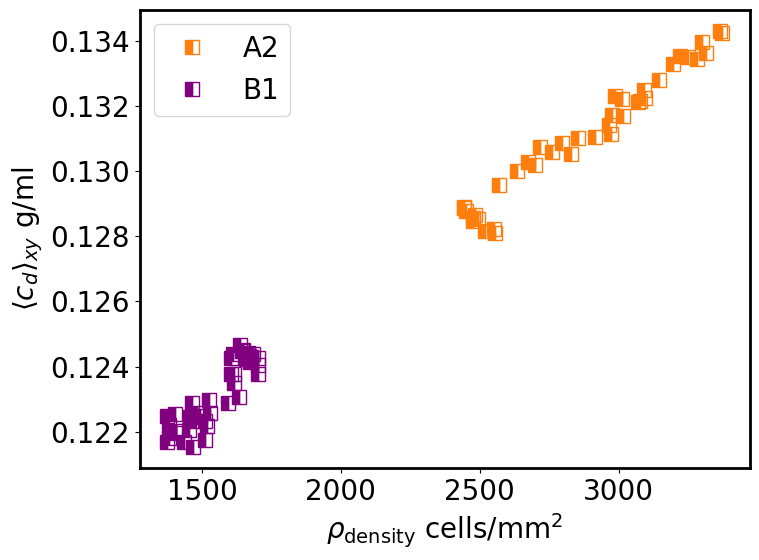

In [6]:
font  = {'size': 20}
lines = {'lw' : 4}
axes  = {'lw' : 2}
mpl.rc('font', **font)
mpl.rc('axes', **axes)
mpl.rc('lines', **lines)
mpl.rc('xtick', labelsize=20)
mpl.rc('ytick', labelsize=20)

fig = plt.figure(figsize=(8,6))
plt.plot(rho_stack[0], (np.mean(n_stack[0], axis=(1,2))-_3DQPI.n0) / 0.19, 's', ms=10, c="tab:orange", label="A2", fillstyle="left")
plt.plot(rho_stack[1], (np.mean(n_stack[1], axis=(1,2))-_3DQPI.n0) / 0.19, 's', ms=10, c="purple",     label="B1", fillstyle="left")

plt.xlabel(r"$\rho_{\text{density}}   ~\text{cells}/\text{mm}{^2}$")
plt.ylabel(r"$\langle c_d \rangle_{xy} ~\text{g}/\text{ml}$")
plt.legend()
plt.tight_layout()
# plt.savefig("figs/SPIE/RI_contrast_evolution.png", dpi=300)

## Plot evolution of each dataset

In [7]:
hcell_arr  = np.concatenate([h_cells[0].ravel() / np.mean(h_cells[0]), 
                             h_cells[1].ravel() / np.mean(h_cells[1])])

cdcell_arr = np.concatenate([cd_cells[0].ravel() / np.mean(cd_cells[0]), 
                             cd_cells[1].ravel() / np.mean(cd_cells[1])])

Number of cells in mean: 55
Number of cells in mean: 447


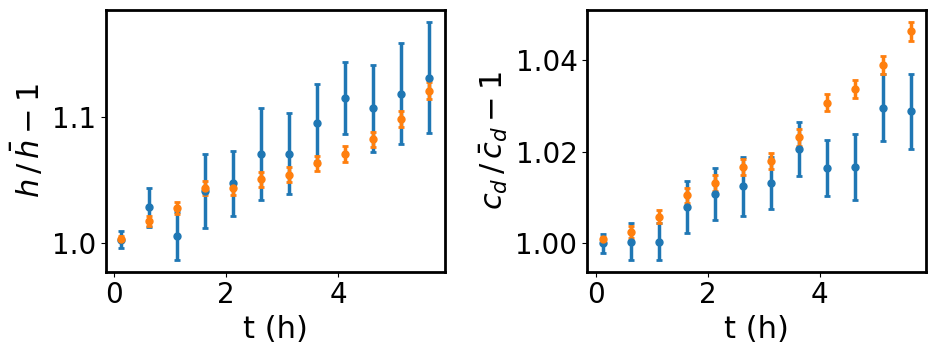

In [8]:
font  = {'size': 22}
lines = {'lw' : 4}
axes  = {'lw' : 2}
mpl.rc('font', **font)
mpl.rc('axes', **axes)
mpl.rc('lines', **lines)
mpl.rc('xtick', labelsize=20)
mpl.rc('ytick', labelsize=20)

fig, ax = plt.subplots(1, 2, figsize=(10,4))

# --- binning helpers ---
bin_size = 2

def bin_1d(x, size):
    n = (len(x) // size) * size   # drop leftover points
    x = np.asarray(x)[:n]
    return x.reshape(-1, size).mean(axis=1)

def bin_err(std, size):
    """
    std: per-point standard deviation (or error) for each time point
    For the mean of N independent points: 
        std_mean = sqrt(sum(std_i^2)) / N
    """
    std = np.asarray(std)
    n = (len(std) // size) * size
    std = std[:n]
    std_sq = (std.reshape(-1, size)**2).sum(axis=1)
    return np.sqrt(std_sq) / size

tmin = 28
tmax = tmin + 12

for i in [1, 0]:
    duration = np.sum(~h_cells[i].mask, axis=0)
    mask = (duration >= tmin) * (duration < tmax)
    print(f"Number of cells in mean: {np.sum(mask):0.0f}")

    h_tmp = []
    c_tmp = []
    for c, h in zip(cd_cells[i][:, mask].T, 
                    h_cells[i][:, mask].T):
        # last tmin points
        c_tmp.append(c.compressed()[-tmin+4:] / c.compressed()[-tmin+4])
        h_tmp.append(h.compressed()[-tmin+4:] / h.compressed()[-tmin+4])

    cd_mean = np.ma.mean(c_tmp, axis=0)
    cd_std  = np.ma.std(c_tmp, axis=0, ddof=1) / np.sqrt(np.sum(mask))

    h_mean = np.ma.mean(h_tmp, axis=0)
    h_std  = np.ma.std(h_tmp, axis=0, ddof=1) / np.sqrt(np.sum(mask))

    time   = np.arange(tmin-4) / 4
    tmask  = time < (tmax - 2) / 4

    # --- apply binning in groups of 4 ---
    time_b  = bin_1d(time[tmask],    bin_size)
    cd_m_b  = bin_1d(cd_mean[tmask], bin_size)
    cd_s_b  = bin_err(cd_std[tmask], bin_size)
    h_m_b   = bin_1d(h_mean[tmask],  bin_size)
    h_s_b   = bin_err(h_std[tmask],  bin_size)

    ax[1].errorbar(time_b, cd_m_b, cd_s_b,
                   fmt=".", lw=2.5, capsize=2, capthick=2, ms=10,
                   label=r"low $\bar{\rho}_{\text{cell}}$")
    ax[0].errorbar(time_b, h_m_b,  h_s_b,
                   fmt=".", lw=2.5, capsize=2, capthick=2, ms=10,
                   label=r"low $\bar{\rho}_{\text{cell}}$")

fig.subplots_adjust(top=0.85, 
                    left=0.2, 
                    bottom=0.15)

ax[1].set(ylabel=r"$c_d \,/\, \bar{c}_d-1$", xlabel="t (h)")
ax[0].set(ylabel=r"$h \,/\, \bar{h}-1$",     xlabel="t (h)")
# ax[0].legend(ncol=2, bbox_to_anchor=(1, 1.3))
fig.tight_layout()
plt.savefig("figs/Elife/subfigures/RI_track_evolution.svg")

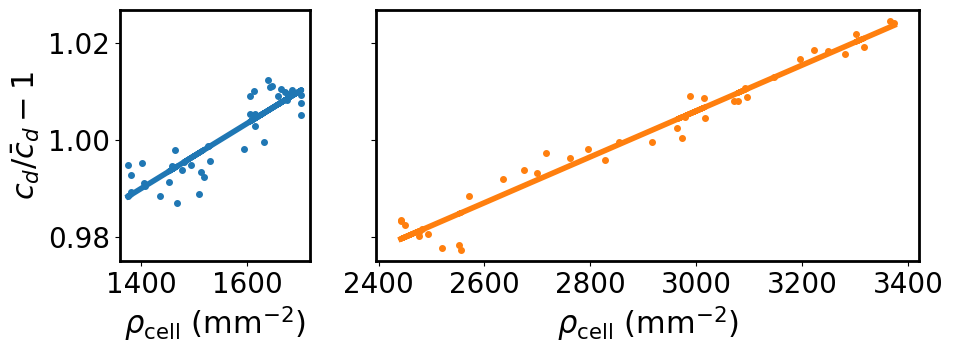

In [9]:

fit_A2 = linregress(rho_stack[0], (np.mean(n_stack[0], axis=(1,2))-_3DQPI.n0) / (np.mean(n_stack[0])-_3DQPI.n0))
fit_B1 = linregress(rho_stack[1], (np.mean(n_stack[1], axis=(1,2))-_3DQPI.n0) / (np.mean(n_stack[1])-_3DQPI.n0))

fig, ax = plt.subplots(1,2, figsize=(10,4), sharey=True, gridspec_kw={'width_ratios':[0.26, 0.74]})
ax[1].plot(rho_stack[0], (np.mean(n_stack[0], axis=(1,2))-_3DQPI.n0) / (np.mean(n_stack[0])-_3DQPI.n0), '.', c="tab:orange", ms=8, label=r"high $\bar{\rho}_{\text{cell}}$")
ax[0].plot(rho_stack[1], (np.mean(n_stack[1], axis=(1,2))-_3DQPI.n0) / (np.mean(n_stack[1])-_3DQPI.n0), '.', c="tab:blue",   ms=8, label=r"low $\bar{\rho}_{\text{cell}}$")

ax[1].plot(rho_stack[0], fit_A2.slope*rho_stack[0] + fit_A2.intercept, c="tab:orange")
ax[0].plot(rho_stack[1], fit_B1.slope*rho_stack[1] + fit_B1.intercept, c="tab:blue")

# ax[1].legend()
# ax[0].legend()
ax[1].set(xlabel=r"$\rho_{\text{cell}}$ (mm$^{-2}$)")
ax[0].set(xlabel=r"$\rho_{\text{cell}}$ (mm$^{-2}$)",
          ylabel=r"$c_d / \bar{c}_d -1$")


fig.tight_layout()

# plt.savefig("figs/Elife/subfigures/RI_fit_evolution.svg")

In [10]:
# Dry mass concentration increase over range of 1000 cell/mm²
print(f"Dense dataset:  {fit_A2.slope * 1000:0.2f}")
print(f"Sparse dataset: {fit_B1.slope * 1000:0.2f}")

Dense dataset:  0.05
Sparse dataset: 0.07


## Compute distribution of dry mass

In [11]:
# Compute blurred fields
n_disc = []
h_disc = []
for n_dataset, h_dataset, rho_dataset in zip(n_stack, 
                                             h_stack, 
                                             rho_stack):

    for n_im, h_im, rho in tqdm(zip(n_dataset[0:39:8], 
                                    h_dataset[0:39:8], 
                                    rho_dataset[0:39:8])):
        
        A_mean = 1/(rho / 10**6)
        r_mean = np.sqrt(A_mean / np.pi)
        sigma  = _3DQPI.rblur * r_mean / _3DQPI.pix_to_um
        print(sigma)

        n_disc.append(gaussian_filter(n_im, sigma))
        h_disc.append(gaussian_filter(h_im, sigma))

0it [00:00, ?it/s]

66.10507300067754


1it [00:05,  5.91s/it]

64.61046252027356


2it [00:11,  5.83s/it]

...

3it [00:22,  7.55s/it]

81.28243614317876


4it [00:30,  7.43s/it]

79.7642627040561


5it [00:37,  7.42s/it]


In [ ]:
frames = [20]

int_n0 = np.concatenate([((n_stack[0][f] - _3DQPI.n0)*h_stack[0][f]).ravel() for f in frames])# 0, 8, 16, 24, 32]])
h0     = np.concatenate([h_stack[0][f].ravel()  for f in frames])# 0, 8, 16, 24, 32]])

int_n1 = np.concatenate([((n_stack[1][f] - _3DQPI.n0)*h_stack[1][f]).ravel() for f in frames])# 0, 8, 16, 24, 32]])
h1     = np.concatenate([h_stack[1][f].ravel()  for f in frames])# 0, 8, 16, 24, 32]])

int_n = np.concatenate([int_n0, int_n1])
h = np.concatenate([h0, h1])

TypeError: 'SegmentedCells' object is not subscriptable

In [89]:
min_bin = np.min(int_n1)
max_bin = np.max(int_n1)
binsize = (max_bin - min_bin) / 20
bins = np.arange(min_bin, max_bin + binsize+1, binsize)

mean_variable = np.zeros(len(bins) - 1)
std_variable  = np.zeros(len(bins) - 1)

idx = np.digitize(int_n1, bins)

for i in range(1, len(bins)):
    idx_in_bin = np.where(idx == i)[0]
    
    mean_variable[i-1] = np.ma.mean(h1[idx_in_bin])
    std_variable[i-1]  = np.ma.std(h1[idx_in_bin]) / np.ma.sqrt(len(idx_in_bin))

/tmp/ipykernel_1305712/1385572897.py:15: UserWarning: Warning: converting a masked element to nan.
  std_variable[i-1]  = np.ma.std(h1[idx_in_bin]) / np.ma.sqrt(len(idx_in_bin))


In [90]:
def func(x, a):
    return x/a

x = 0.5*(bins[1:] + bins[:-1])
y = np.nan_to_num(mean_variable)
s = np.nan_to_num(std_variable)

mask = (y > 0) * (s > 0)
x = x[mask]
y = y[mask]
s = s[mask]

param,  popt  = curve_fit(func, x, y, sigma=s)

print(f"Slope:     {param[0]:0.8f} +/- {popt[0,0]:0.8f}")
print(f"\nDry mass concentration: {param[0] / 0.19:0.4f} +/- {popt[0,0] / 0.19:0.4f}")

Slope:     0.02536358 +/- 0.00000090

Dry mass concentration: 0.1335 +/- 0.0000


In [91]:
# Compute PDF of dry mass concentration
cd_im = np.array([(n -_3DQPI.n0)  / (np.mean(n) - _3DQPI.n0) for n in n_disc])

h_im  = np.array(h_disc / np.mean(h_disc, axis=(1,2), keepdims=True))


In [111]:

xn, yn = compute_pdf_from_bins(cd_im.ravel(), 1000, sigma=1)
xh, yh = compute_pdf_from_bins(h_im.ravel(),  30, sigma=1)

yh *= max(yn) / max(yh)

np.std(cd_im), np.std(h_im), np.std(h_im)/np.std(cd_im)

(np.float64(0.04462316322122029),
 np.float64(0.21604793495539287),
 np.float64(4.84160958926938))

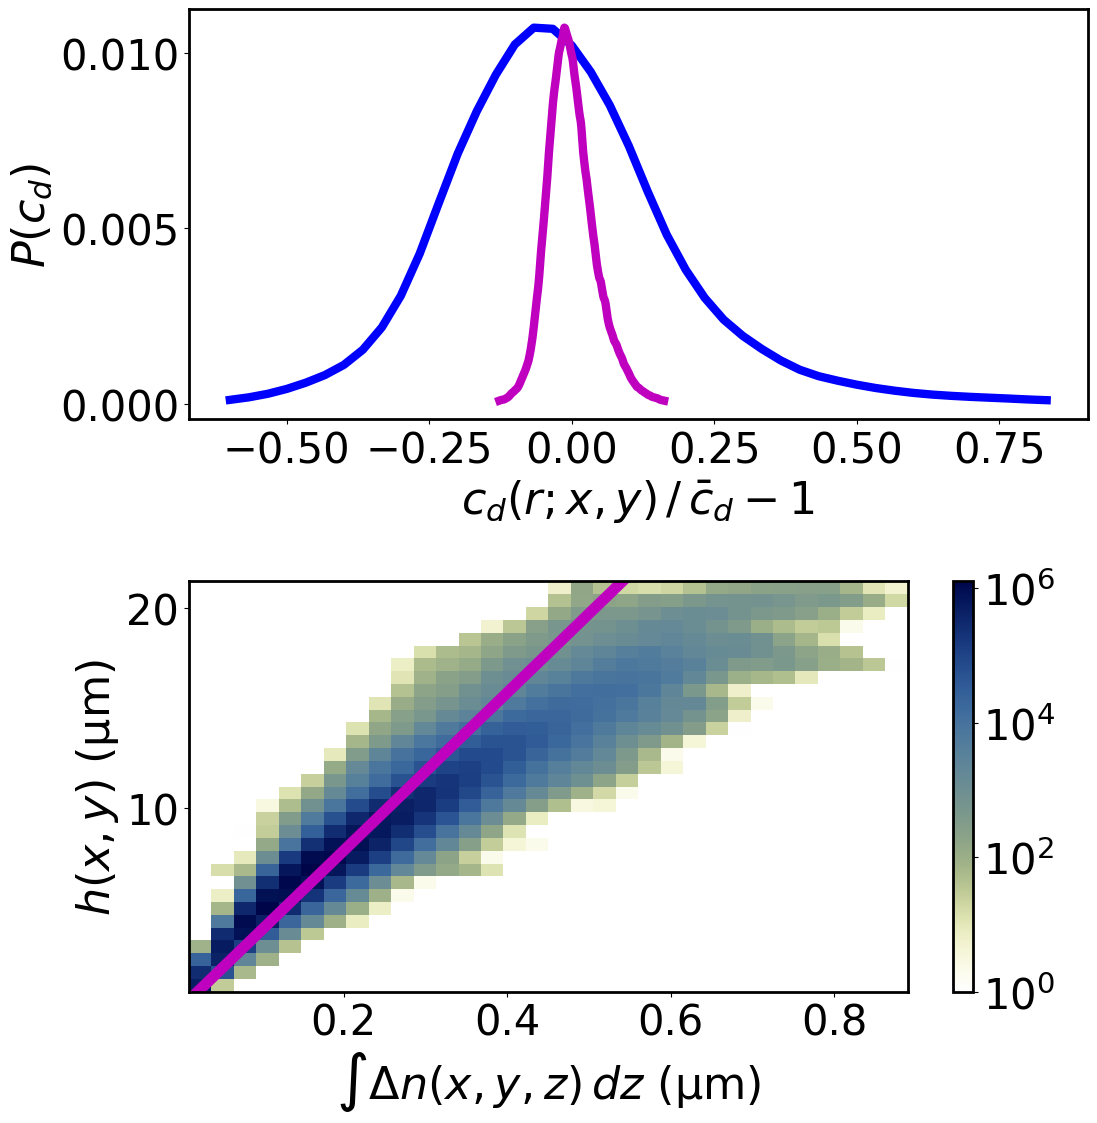

In [112]:
# Plot
# plot parameters
font  = {'size': 32}
lines = {'lw' : 4}
axes  = {'lw' : 2}
mpl.rc('font', **font)
mpl.rc('axes', **axes)
mpl.rc('lines', **lines)
mpl.rc('xtick', labelsize=30)
mpl.rc('ytick', labelsize=30)


fig, ax = plt.subplots(2, 1, figsize=(12,12))

mask_n = yn > 1e-4 #abs((xn-1)) < 0.2
mask_h = yh > 1e-4 #abs((xh-1)) < 0.8

ax[0].plot((xh-1)[mask_h], yh[mask_h], '-', c='b', lw=6)
ax[0].plot((xn-1)[mask_n], yn[mask_n], '-', c='m', lw=6)

ax[0].set(xlabel=r"$c_d(r;x,y)\,/\,\bar{c}_d-1$",
          ylabel=r"$P(c_d)$")

im = ax[1].hist2d(int_n, h, bins=[32, 32], norm=mpl.colors.LogNorm(), cmap=cm.davos_r);
fig.colorbar(im[3], ax=ax[1])

x = np.linspace(0, 0.6, 10)
ax[1].plot(x, func(x, param), '-', c="m", lw=8)


ax[1].set(ylabel=r"$h(x,y)$ (µm)",
          xlabel=r"$\int \Delta n(x,y,z)\,dz$ (µm)",
          )
fig.tight_layout()
# fig.savefig("figs/Elife/subfigures/hcd_correlation.png", dpi=300)